In [ ]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline

import os
import pygmt
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors
import numpy as np
from matplotlib.patches import Ellipse
import pandas as pd 
from matplotlib.colors import LinearSegmentedColormap
import glob 
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LogNorm
from scipy.spatial import ConvexHull
import matplotlib.patches as patches
import alphashape
from descartes import PolygonPatch
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
import utils

In [ ]:
reference_benchmark_interevent_times = pd.read_csv(
    "code_output_data/interevent_times_benchmarks.csv"
)
two_faults_interevent_times = pd.read_csv(
    "code_output_data/interevent_times_two_faults_full_ruptures.csv"
)
two_faults_order = two_faults_interevent_times.copy()
two_faults_order["phase_f1"] = None
two_faults_order["order_parameter_f1"] = None
two_faults_order["phase_f2"] = None
two_faults_order["order_parameter_f2"] = None
two_faults_order["mean_time_diff_f1"] = None
two_faults_order["mean_time_diff_f2"] = None
two_faults_order["normalized_mean_time_diff_f1"] = None
two_faults_order["normalized_mean_time_diff_f2"] = None
two_faults_order["variance_f1"] = None
two_faults_order["variance_f2"] = None

shear_mod = 30e9  # Shear modulus in Pa
a = 1e-2
b = a + 4e-3
sigma_o = 100e6  # normal stress Pa
L = 5000  # rate-weakening length

FileNotFoundError: [Errno 2] No such file or directory: 'code_output_data/interevent_times_benchmarks.csv'

In [ ]:
unique_combinations = reference_benchmark_interevent_times[["Dc", "Loading"]]

for _, row in unique_combinations.iterrows():
    dc = row["Dc"]
    Ru = utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L)
    loading = row["Loading"]

    # benchmark times
    benchmark_row = reference_benchmark_interevent_times[
        (reference_benchmark_interevent_times["Dc"] == dc)
        & (reference_benchmark_interevent_times["Loading"] == loading)
    ]
    times_benchmark = [
        float(x) for x in benchmark_row["Inter-event times (years)"].iloc[0].split(",")
    ]
    times_benchmark = np.array(times_benchmark)

    two_faults_rows = two_faults_order[
        (two_faults_order["Dc"] == dc) & (two_faults_order["Loading"] == loading)
    ]

    for _, two_faults_row in two_faults_rows.iterrows():
        d = two_faults_row["D"]
        times_f1 = [
            float(x)
            for x in two_faults_row["Inter-event times fault 1 (years)"].split(",")
        ]
        times_f2 = [
            float(x)
            for x in two_faults_row["Inter-event times fault 2 (years)"].split(",")
        ]

        print("D/L", d / 5, "Ru = ", Ru, loading)
        mean_benchmark = np.mean(times_benchmark)
        variance_benchmark = np.var(times_benchmark)
        print("Mean benchmark", mean_benchmark)
        mean_f1 = np.mean(times_f1)
        print("Mean f1", mean_f1)
        mean_f2 = np.mean(times_f2)
        print("Mean f2", mean_f2)
        variance_f1 = np.var(times_f1)
        variance_f2 = np.var(times_f2)

        mean_f1_diff = mean_f1 - mean_benchmark
        mean_f2_diff = mean_f2 - mean_benchmark

        mask = (
            (two_faults_order["Dc"] == dc)
            & (two_faults_order["Loading"] == loading)
            & (two_faults_order["D"] == d)
        )
        two_faults_order.loc[mask, "mean_benchmark"] = mean_benchmark
        two_faults_order.loc[mask, "mean_f1"] = mean_f1
        two_faults_order.loc[mask, "mean_f2"] = mean_f2
        two_faults_order.loc[mask, "mean_f1_diff"] = mean_f1_diff
        two_faults_order.loc[mask, "mean_f2_diff"] = mean_f2_diff
        two_faults_order.loc[mask, "normalized_mean_time_diff_f1"] = (
            mean_f1_diff / mean_benchmark
        )
        two_faults_order.loc[mask, "normalized_mean_time_diff_f2"] = (
            mean_f2_diff / mean_benchmark
        )
        two_faults_order.loc[mask, "variance_f1"] = variance_f1
        two_faults_order.loc[mask, "variance_f2"] = variance_f2
        two_faults_order.loc[mask, "normalized_variance_f1"] = np.log10(
            variance_f1 / variance_benchmark
        )
        two_faults_order.loc[mask, "normalized_variance_f2"] = np.log10(
            variance_f2 / variance_benchmark
        )

        print("Variance benchmark", variance_benchmark)
        print("Variance f1", variance_f1)
        print("Variance f2", variance_f2)
        print("norm Variance f1", variance_f1 / variance_benchmark)
        print("norm Variance f2", variance_f2 / variance_benchmark)
        print("")

D/L 0.2 Ru =  6.666666666666667 In plane
Mean benchmark 39.2170932714596
Mean f1 41.1541412003992
Mean f2 41.15079042881819
Variance benchmark 1.0029170000377264e-12
Variance f1 3.518135496477688e-07
Variance f2 2.9937853601878286e-06
norm Variance f1 350790.29434592766
norm Variance f2 2985077.8878762773

D/L 0.6 Ru =  6.666666666666667 In plane
Mean benchmark 39.2170932714596
Mean f1 39.28133406343386
Mean f2 39.28113647669013
Variance benchmark 1.0029170000377264e-12
Variance f1 0.00016488648569922606
Variance f2 0.0001771181966970216
norm Variance f1 164406910.7344113
norm Variance f2 176603045.60632536

D/L 1.0 Ru =  6.666666666666667 In plane
Mean benchmark 39.2170932714596
Mean f1 39.27319287861332
Mean f2 39.27299664609493
Variance benchmark 1.0029170000377264e-12
Variance f1 0.00013504395185474937
Variance f2 0.00014059729833147198
norm Variance f1 134651174.37402046
norm Variance f2 140188368.85423538

D/L 2.0 Ru =  6.666666666666667 In plane
Mean benchmark 39.2170932714596
M

### Theoretical interevent time

T_inter = stress_drop/mu_star * L/vload

In [ ]:
mu_star_antiplane = 30*10**9 # Pa
mu_star_inplane = mu_star_antiplane/(1-0.3)# Pa
L_eff = 7000 # m
vload = 10**-9 # m/s
stress_drop = 7*10**6 # Pa

T_inter_antiplane = (stress_drop/mu_star_antiplane) * (L_eff/vload)
T_inter_inplane = (stress_drop/mu_star_inplane) * (L_eff/vload)

print(T_inter_antiplane/365/24/60/60, T_inter_inplane/365/24/60/60)

51.79266024014883 36.254862168104175


In plane, D/L=0.0, Dc=0.01, Ru=6.7
  F1: mean=38.358378, std=35.346778
  F2: mean=38.096273, std=30.724993
In plane, D/L=0.1, Dc=0.01, Ru=6.7
  F1: mean=39.525989, std=19.062586
  F2: mean=38.524554, std=18.576316
In plane, D/L=0.2, Dc=0.01, Ru=6.7
  F1: mean=41.154141, std=0.000593
  F2: mean=41.150790, std=0.001730
In plane, D/L=0.3, Dc=0.01, Ru=6.7
  F1: mean=40.544850, std=0.011623
  F2: mean=40.538614, std=0.007180
In plane, D/L=0.6, Dc=0.01, Ru=6.7
  F1: mean=39.281334, std=0.012841
  F2: mean=39.281136, std=0.013309
In plane, D/L=1.0, Dc=0.01, Ru=6.7
  F1: mean=39.273193, std=0.011621
  F2: mean=39.272997, std=0.011857
In plane, D/L=2.0, Dc=0.01, Ru=6.7
  F1: mean=39.203871, std=0.012835
  F2: mean=39.203801, std=0.012859
In plane, D/L=4.0, Dc=0.01, Ru=6.7
  F1: mean=39.138949, std=0.016070
  F2: mean=39.135532, std=0.018691
In plane, D/L=6.0, Dc=0.01, Ru=6.7
  F1: mean=39.169968, std=0.014486
  F2: mean=39.158334, std=0.021572
In plane, D/L=12.0, Dc=0.01, Ru=6.7
  F1: mean=39.2

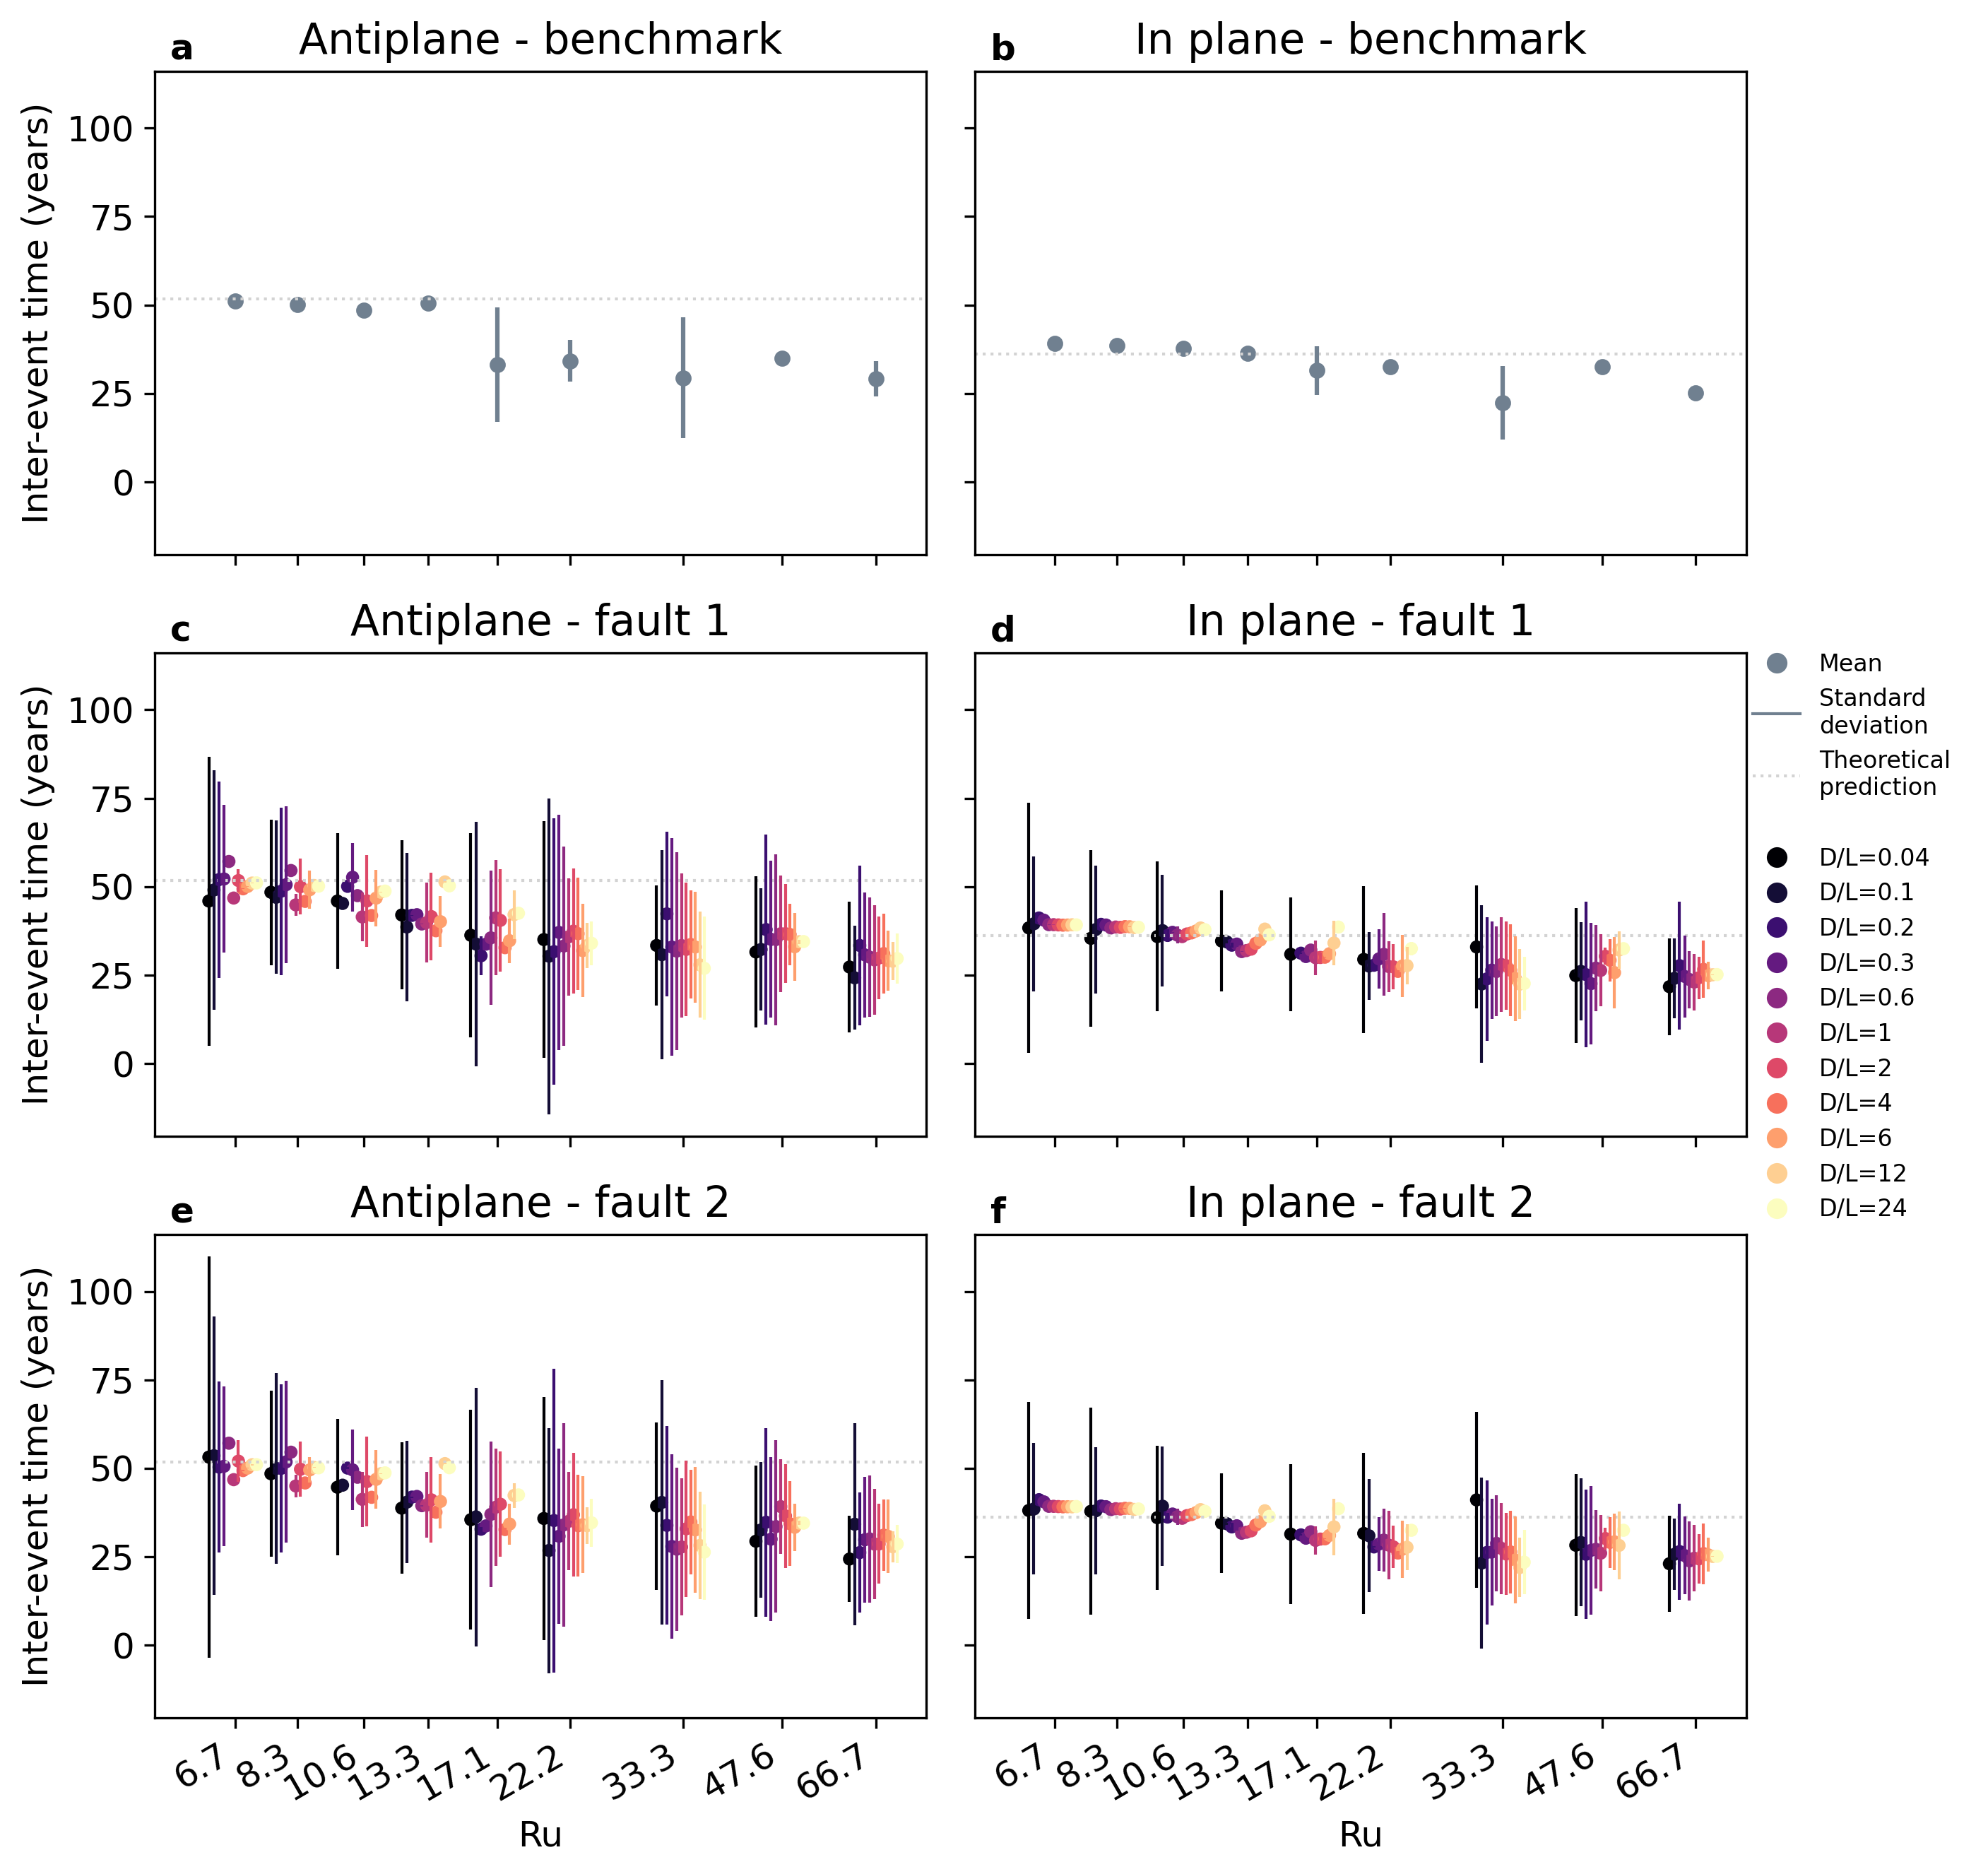

In [ ]:
unique_combinations = reference_benchmark_interevent_times[['Dc', 'Loading']].copy()
# Sort by Ru for proper ordering
unique_combinations['Ru'] = unique_combinations['Dc'].apply(lambda dc: utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L))
unique_combinations = unique_combinations.sort_values('Ru')

plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(3, 2, dpi=300, figsize=(8.5,9), sharex=True, sharey=True)
Ruref  = []

D_values = np.sort(two_faults_order['D'].unique())
colors_D = plt.cm.magma(np.linspace(0, 1, len(D_values)))
color_map_D = dict(zip(D_values, colors_D))

factors = np.linspace(0.91, 1.08, len(D_values))
d_to_factor = dict(zip(D_values, factors))
# Add theoretical lines to all antiplane and in plane panels
for row_idx in range(3):
    axes[row_idx, 1].axhline(T_inter_inplane/365/24/60/60, color='lightgray', linestyle=':', linewidth=1)
    axes[row_idx, 0].axhline(T_inter_antiplane/365/24/60/60, color='lightgray', linestyle=':', linewidth=1)

for _, row in unique_combinations.iterrows():
    dc = row['Dc']
    Ru = utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L)
    Ruref.append(Ru)
    loading = row['Loading']
    
    # benchmark times
    benchmark_row = reference_benchmark_interevent_times[
        (reference_benchmark_interevent_times['Dc'] == dc) & 
        (reference_benchmark_interevent_times['Loading'] == loading)
    ]
    times_benchmark = [float(x) for x in benchmark_row['Inter-event times (years)'].iloc[0].split(',')]
    times_benchmark = np.array(times_benchmark)
    mean_benchmark = np.mean(times_benchmark)
    std_benchmark = np.std(times_benchmark)
    
    if loading == 'Antiplane':
        axes[0,0].scatter(Ru, mean_benchmark, c='slategray', s=20)
        axes[0,0].errorbar(Ru, mean_benchmark, yerr=std_benchmark, c='slategray')
        axes[0,0].set_title('Antiplane - benchmark')
        axes[0,0].set_xscale('log')
        axes[0,0].set_ylabel('Inter-event time (years)')
    elif loading == 'In plane':
        axes[0,1].scatter(Ru, mean_benchmark, c='slategray', s=20)
        axes[0,1].errorbar(Ru, mean_benchmark, yerr=std_benchmark, c='slategray')
        axes[0,1].set_title('In plane - benchmark')
        axes[0,1].set_xscale('log')

    two_faults_rows = two_faults_order[
        (two_faults_order['Dc'] == dc) & 
        (two_faults_order['Loading'] == loading)
    ]

    
    for d in D_values:
        factor = d_to_factor[d]
        color = color_map_D[d]
        row_match = two_faults_rows[two_faults_rows['D'] == d]
        if row_match.empty:
            continue
        two_faults_row = row_match.iloc[0]
        times_f1 = [float(x) for x in two_faults_row['Inter-event times fault 1 (years)'].split(',')]
        times_f2 = [float(x) for x in two_faults_row['Inter-event times fault 2 (years)'].split(',')]
        mean_f1 = np.mean(times_f1)
        mean_f2 = np.mean(times_f2)
        std_f1 = np.std(times_f1)
        std_f2 = np.std(times_f2)
        
        # Print statistics for debugging
        print(f"{loading}, D/L={d/5:.1f}, Dc={dc}, Ru={Ru:.1f}")
        print(f"  F1: mean={mean_f1:.6f}, std={std_f1:.6f}")
        print(f"  F2: mean={mean_f2:.6f}, std={std_f2:.6f}")
        
        jRu = Ru * factor

        if loading == 'Antiplane':
            # Panel c: Antiplane Fault 1
            axes[1,0].errorbar(jRu, mean_f1, yerr=std_f1, color=color,lw=1)
            axes[1,0].scatter(jRu, mean_f1, s=20, color=color,edgecolor='none')   
            axes[1,0].set_xscale('log')
            axes[1,0].set_ylabel('Inter-event time (years)')
            axes[1,0].set_title('Antiplane - fault 1')
            
            # Panel e: Antiplane Fault 2
            axes[2,0].errorbar(jRu, mean_f2, yerr=std_f2, color=color,lw=1)
            axes[2,0].scatter(jRu, mean_f2, s=20, color=color,edgecolor='none')
            axes[2,0].set_xscale('log')
            axes[2,0].set_ylabel('Inter-event time (years)')
            axes[2,0].set_xlabel('Ru')
            axes[2,0].set_title('Antiplane - fault 2')
            
        elif loading == 'In plane':
            # Panel d: In plane Fault 1
            axes[1,1].errorbar(jRu, mean_f1, yerr=std_f1, color=color,lw=1)
            axes[1,1].scatter(jRu, mean_f1, s=20, color=color,edgecolor='none')
            axes[1,1].set_xscale('log')
            axes[1,1].set_title('In plane - fault 1')
            
            # Panel f: In plane Fault 2
            axes[2,1].errorbar(jRu, mean_f2, yerr=std_f2, color=color,lw=1)
            axes[2,1].scatter(jRu, mean_f2, s=20, color=color,edgecolor='none')
            axes[2,1].set_xscale('log')
            axes[2,1].set_xlabel('Ru')
            axes[2,1].set_title('In plane - fault 2')

legend_elements_D = []
benchmark_dot = Line2D([0], [0], marker='o', color='slategray', markersize=6, linestyle='None', label='Mean')
benchmark_std = Line2D([0], [0], color='slategray', linewidth=1, marker=None, linestyle='-', label='Standard \ndeviation')
theoretical_line = Line2D([0], [0], color='lightgray', linewidth=1, marker=None, linestyle=':', label='Theoretical \nprediction')
benchmark_space= Line2D([0], [0], color='white', linewidth=1, marker=None, linestyle='-', label='')

for d in D_values:
    d_over_5 = d / 5
    if d_over_5.is_integer():
        label = f'D/L={int(d_over_5)}'
    elif d_over_5 < 0.1:
        label = f'D/L={d_over_5:.2f}'
    else:
        label = f'D/L={d_over_5:.1f}'

    legend_elements_D.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map_D[d], 
                                markersize=8, label=label))
    
legend_elements = [benchmark_dot, benchmark_std, theoretical_line, benchmark_space] + legend_elements_D
fig.legend(handles=legend_elements, loc='center right', frameon=False, bbox_to_anchor=(1.108, 0.5), fontsize=8)

desired_ticks = np.unique(Ruref)
for ax in axes.flat:
    ax.set_xscale('log')
    ax.set_xticklabels([])
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set_xticks(desired_ticks)
    ax.set_xticklabels([f"{tick:.1f}" for tick in desired_ticks], rotation=30, ha='right')
    ax.set_xlim(5,80)
tags = ['a', 'b', 'c', 'd', 'e', 'f']
for idx, ax in enumerate(axes.flat):
    ax.text(0.02, 1.08, tags[idx], transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
plt.tight_layout()
plt.savefig('Summary figures/interevent_order_plots_tables/inter_event_times.png', dpi=300, bbox_inches='tight')

### Distribution of inter-event times

Faults vs benchmark fault

In [ ]:
# for col in ['mean_benchmark', 'mean_f1', 'mean_f2', 'mean_f1_diff', 'mean_f2_diff']:
#     two_faults_order[col] = pd.to_numeric(two_faults_order[col], errors='coerce')

# header = "| Dc | Loading | D | mean_benchmark | mean_f1 | mean_f2 | mean_f1_diff | mean_f2_diff |\n"
# header += "|----|---------|---|----------------|---------|---------|--------------|--------------|\n"
# rows = ""
# for _, row in two_faults_order.iterrows():
#     rows += f"| {row['Dc']} | {row['Loading']} | {row['D']} | {row['mean_benchmark']:.3f} | {row['mean_f1']:.3f} | {row['mean_f2']:.3f} | {row['mean_f1_diff']:.3f} | {row['mean_f2_diff']:.3f} |\n"

# markdown_table = header + rows
# print(markdown_table)
# utils.markdown_table_to_pdf(markdown_table, 'Summary figures/interevent_order_plots_tables/interevent_times.pdf')

In [ ]:
D_range = np.array([0.2, 0.5, 1, 1.7, 3, 5, 10, 20, 30, 60, 120]) * 10**3
Dc = np.array([0.01, 0.008, 0.0063, 0.005, 0.0039, 0.003, 0.002, 0.0014, 0.001])
D_W_values = np.array([utils.estimate_D_W_ratio(D, L) for D in D_range])
Ru_values = np.array([utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L) for dc in Dc])
h_star_values = np.array(
    [utils.estimate_h_star(shear_mod, dc, b, a, sigma_o) for dc in Dc]
)

/var/folders/kg/j5ms0y1x28l_gm2jtsf5j4pr0000gn/T/ipykernel_5085/85485171.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.89, 1])


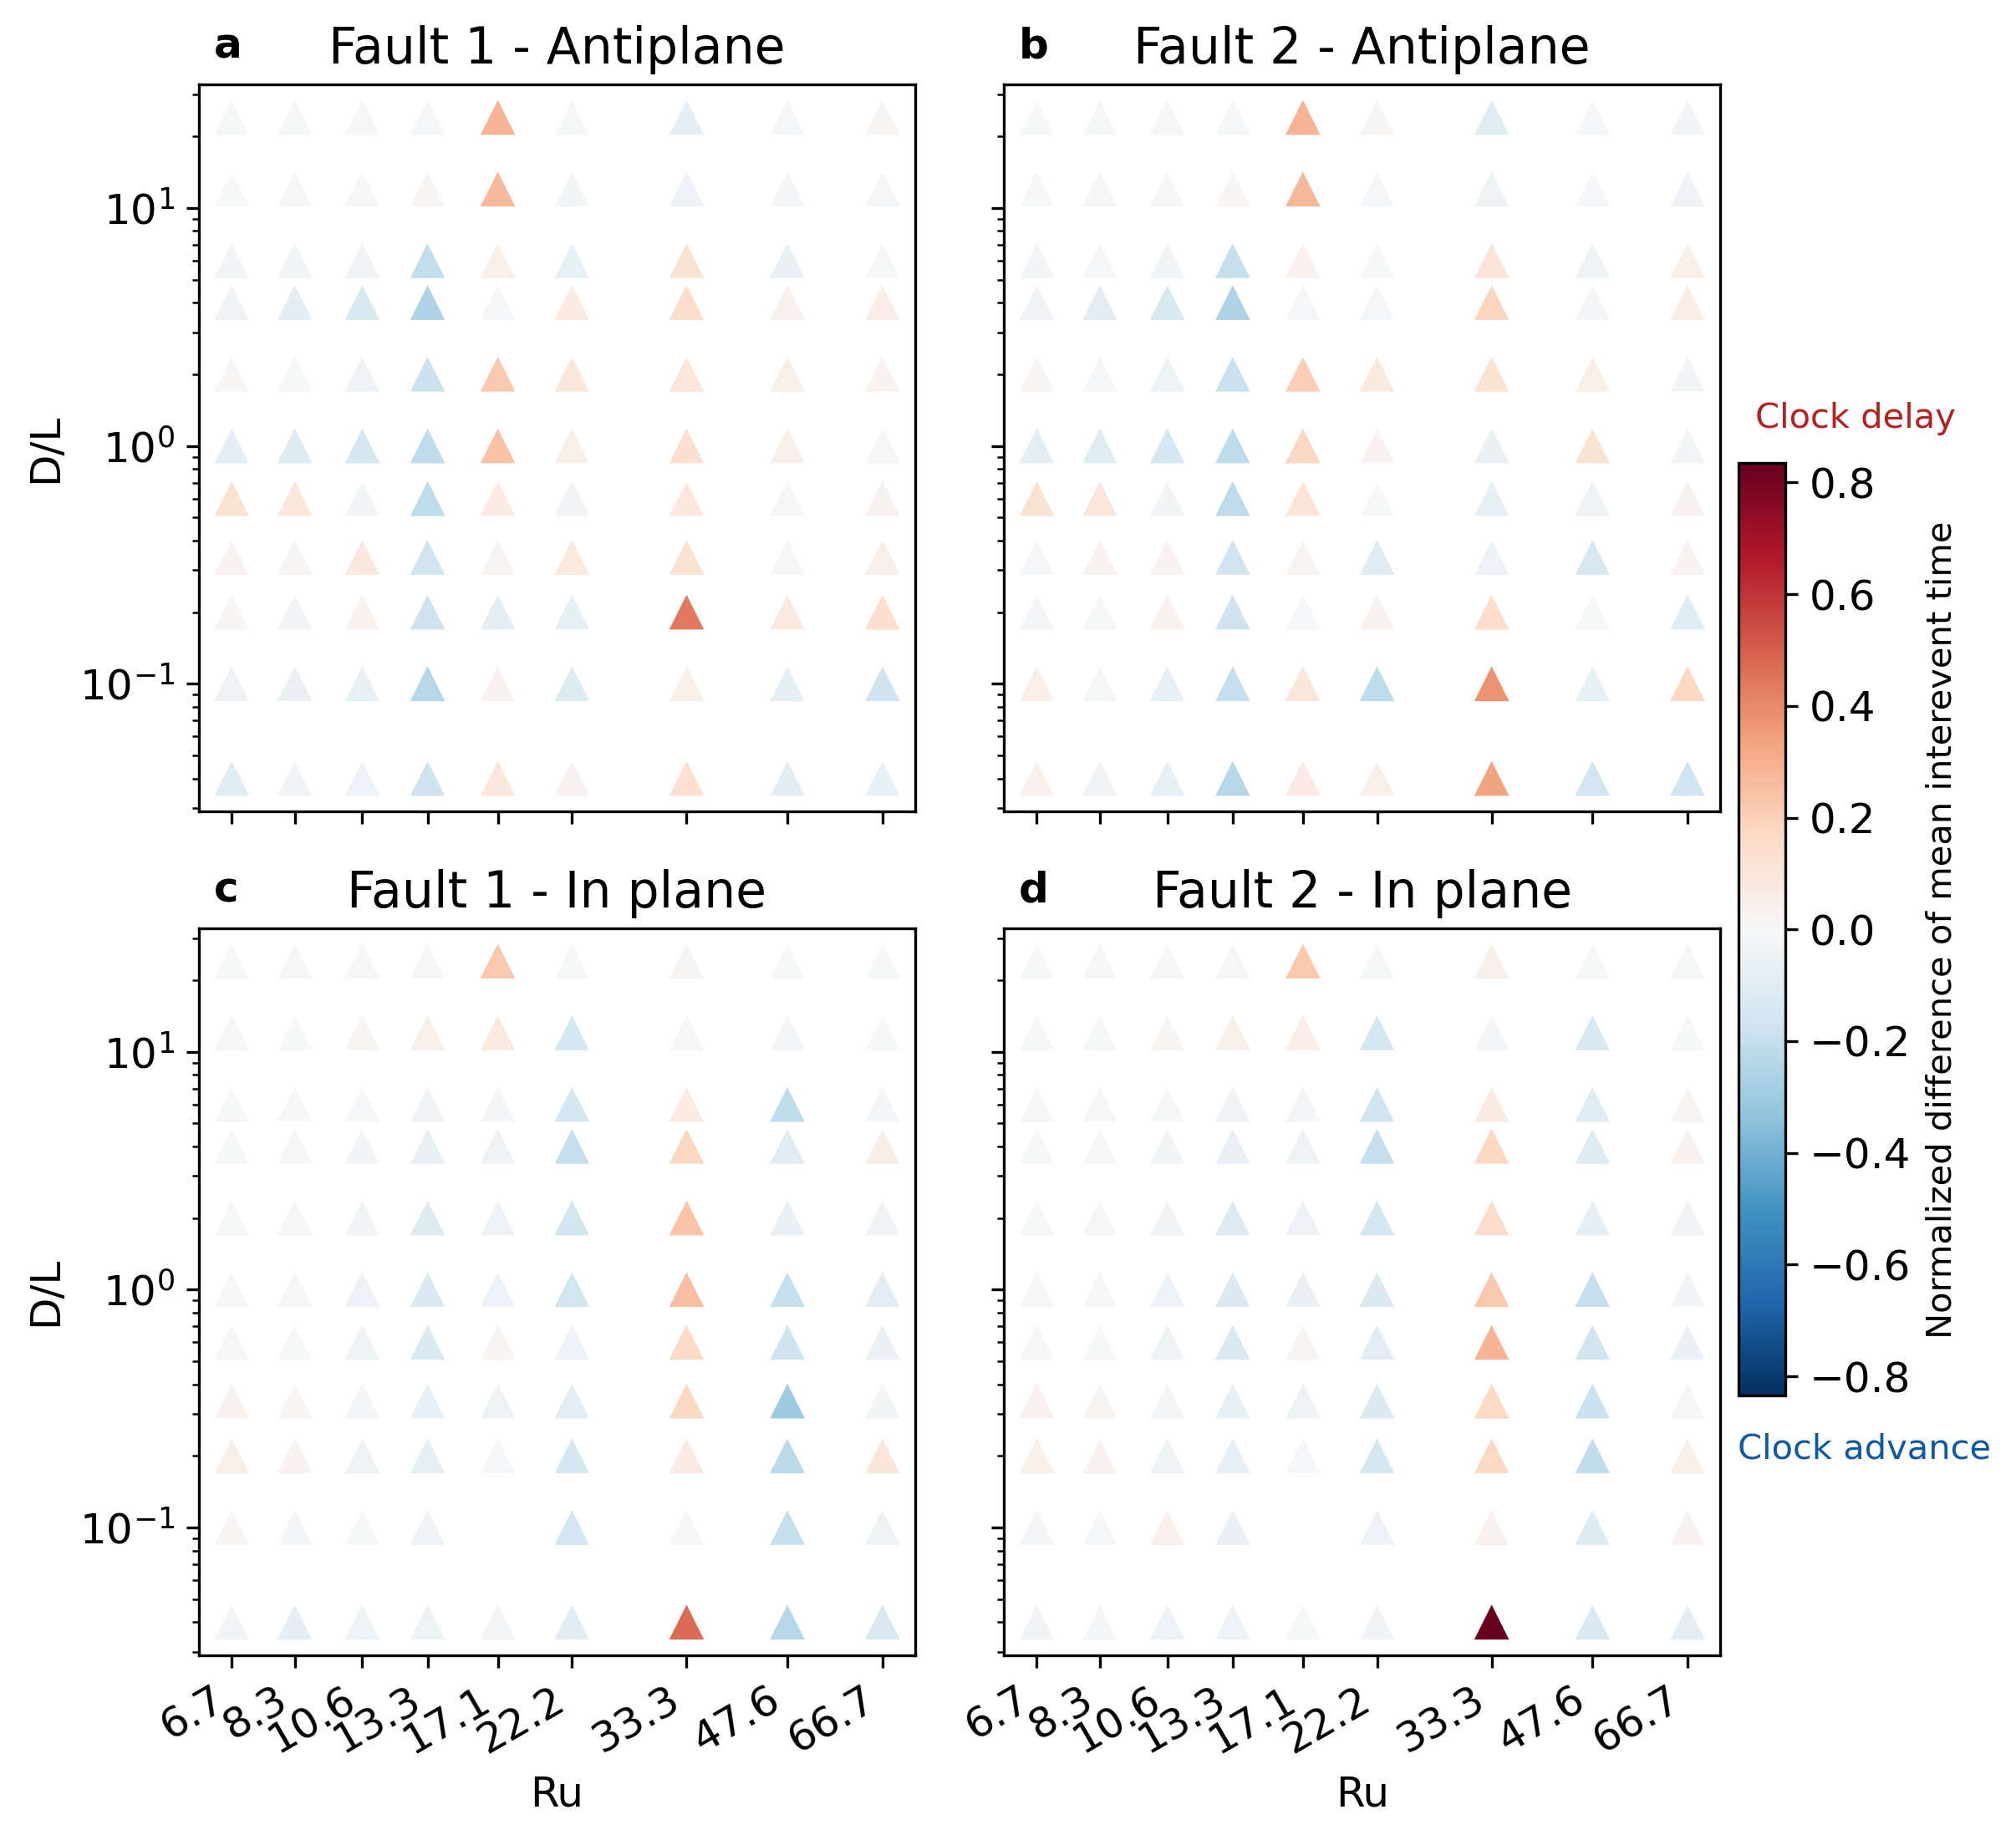

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7.5), dpi=300, sharex=True, sharey=True)

scatter = None

# to center cbar at 0
all_vals = pd.concat(
    [
        two_faults_order["normalized_mean_time_diff_f1"],
        two_faults_order["normalized_mean_time_diff_f2"],
    ]
).dropna()
vmax = all_vals.abs().max()
vmin = -vmax
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

for i, loading in enumerate(["Antiplane", "In plane"]):
    data = two_faults_order[
        two_faults_order["Loading"].str.strip().str.lower() == loading.lower()
    ].copy()
    data["D"] = pd.to_numeric(data["D"], errors="coerce")
    data["Dc"] = pd.to_numeric(data["Dc"], errors="coerce")

    data["Ru"] = [
        utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L) for dc in data["Dc"]
    ]
    data["normalized_mean_time_diff_f1"] = pd.to_numeric(
        data["normalized_mean_time_diff_f1"], errors="coerce"
    )
    data["normalized_mean_time_diff_f2"] = pd.to_numeric(
        data["normalized_mean_time_diff_f2"], errors="coerce"
    )

    scatter = axes[i, 0].scatter(
        data["Ru"],
        data["D"] / 5,
        c=data["normalized_mean_time_diff_f1"],
        cmap="RdBu_r",
        marker="^",
        edgecolor="none",
        s=100,
        norm=norm,
    )
    axes[i, 0].set_title(f"Fault 1 - {loading}")
    axes[0, 0].set_ylabel("D/L")
    axes[1, 0].set_xlabel("Ru")
    axes[i, 0].set_xscale("log")
    axes[i, 0].set_yscale("log")
    axes[i, 0].set_xticklabels([])
    axes[i, 0].xaxis.set_minor_locator(plt.NullLocator())
    if loading == "Antiplane":
        desired_ticks = data["Ru"].unique()

    axes[i, 0].set_xticks(desired_ticks)
    axes[i, 0].set_xticklabels(
        [f"{tick:.1f}" for tick in desired_ticks], rotation=30, ha="right"
    )

    scatter = axes[i, 1].scatter(
        data["Ru"],
        data["D"] / 5,
        c=data["normalized_mean_time_diff_f2"],
        cmap="RdBu_r",
        edgecolor="none",
        marker="^",
        s=100,
        norm=norm,
    )
    axes[i, 1].set_title(f"Fault 2 - {loading}")
    axes[1, 0].set_ylabel("D/L")
    axes[1, 1].set_xlabel("Ru")
    axes[i, 1].set_yscale("log")
    axes[i, 1].set_xscale("log")
    axes[i, 1].set_xticklabels([])
    axes[i, 1].xaxis.set_minor_locator(plt.NullLocator())
    axes[i, 1].set_xticks(desired_ticks)
    axes[i, 1].set_xticklabels(
        [f"{tick:.1f}" for tick in desired_ticks], rotation=30, ha="right"
    )


cbar = fig.colorbar(scatter, ax=axes, orientation="vertical", fraction=0.03, pad=0.03)
cbar.set_label("Normalized difference of mean interevent time", fontsize=10)
cbar.ax.text(
    2.5,
    1.03,
    "Clock delay",
    ha="center",
    va="bottom",
    fontsize=10,
    transform=cbar.ax.transAxes,
    color="firebrick",
)
cbar.ax.text(
    2.7,
    -0.04,
    "Clock advance",
    ha="center",
    va="top",
    fontsize=10,
    transform=cbar.ax.transAxes,
    color="#0F58A4",
)

tags = ["a", "b", "c", "d"]
for idx, ax in enumerate(axes.flat):
    ax.text(
        0.02,
        1.08,
        tags[idx],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left",
    )
fig.subplots_adjust(wspace=0.1)
plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.savefig(
    "Summary figures/interevent_order_plots_tables/phase_space_time_normalized.png",
    bbox_inches="tight",
)

/var/folders/kg/j5ms0y1x28l_gm2jtsf5j4pr0000gn/T/ipykernel_5085/77677689.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.89, 1])


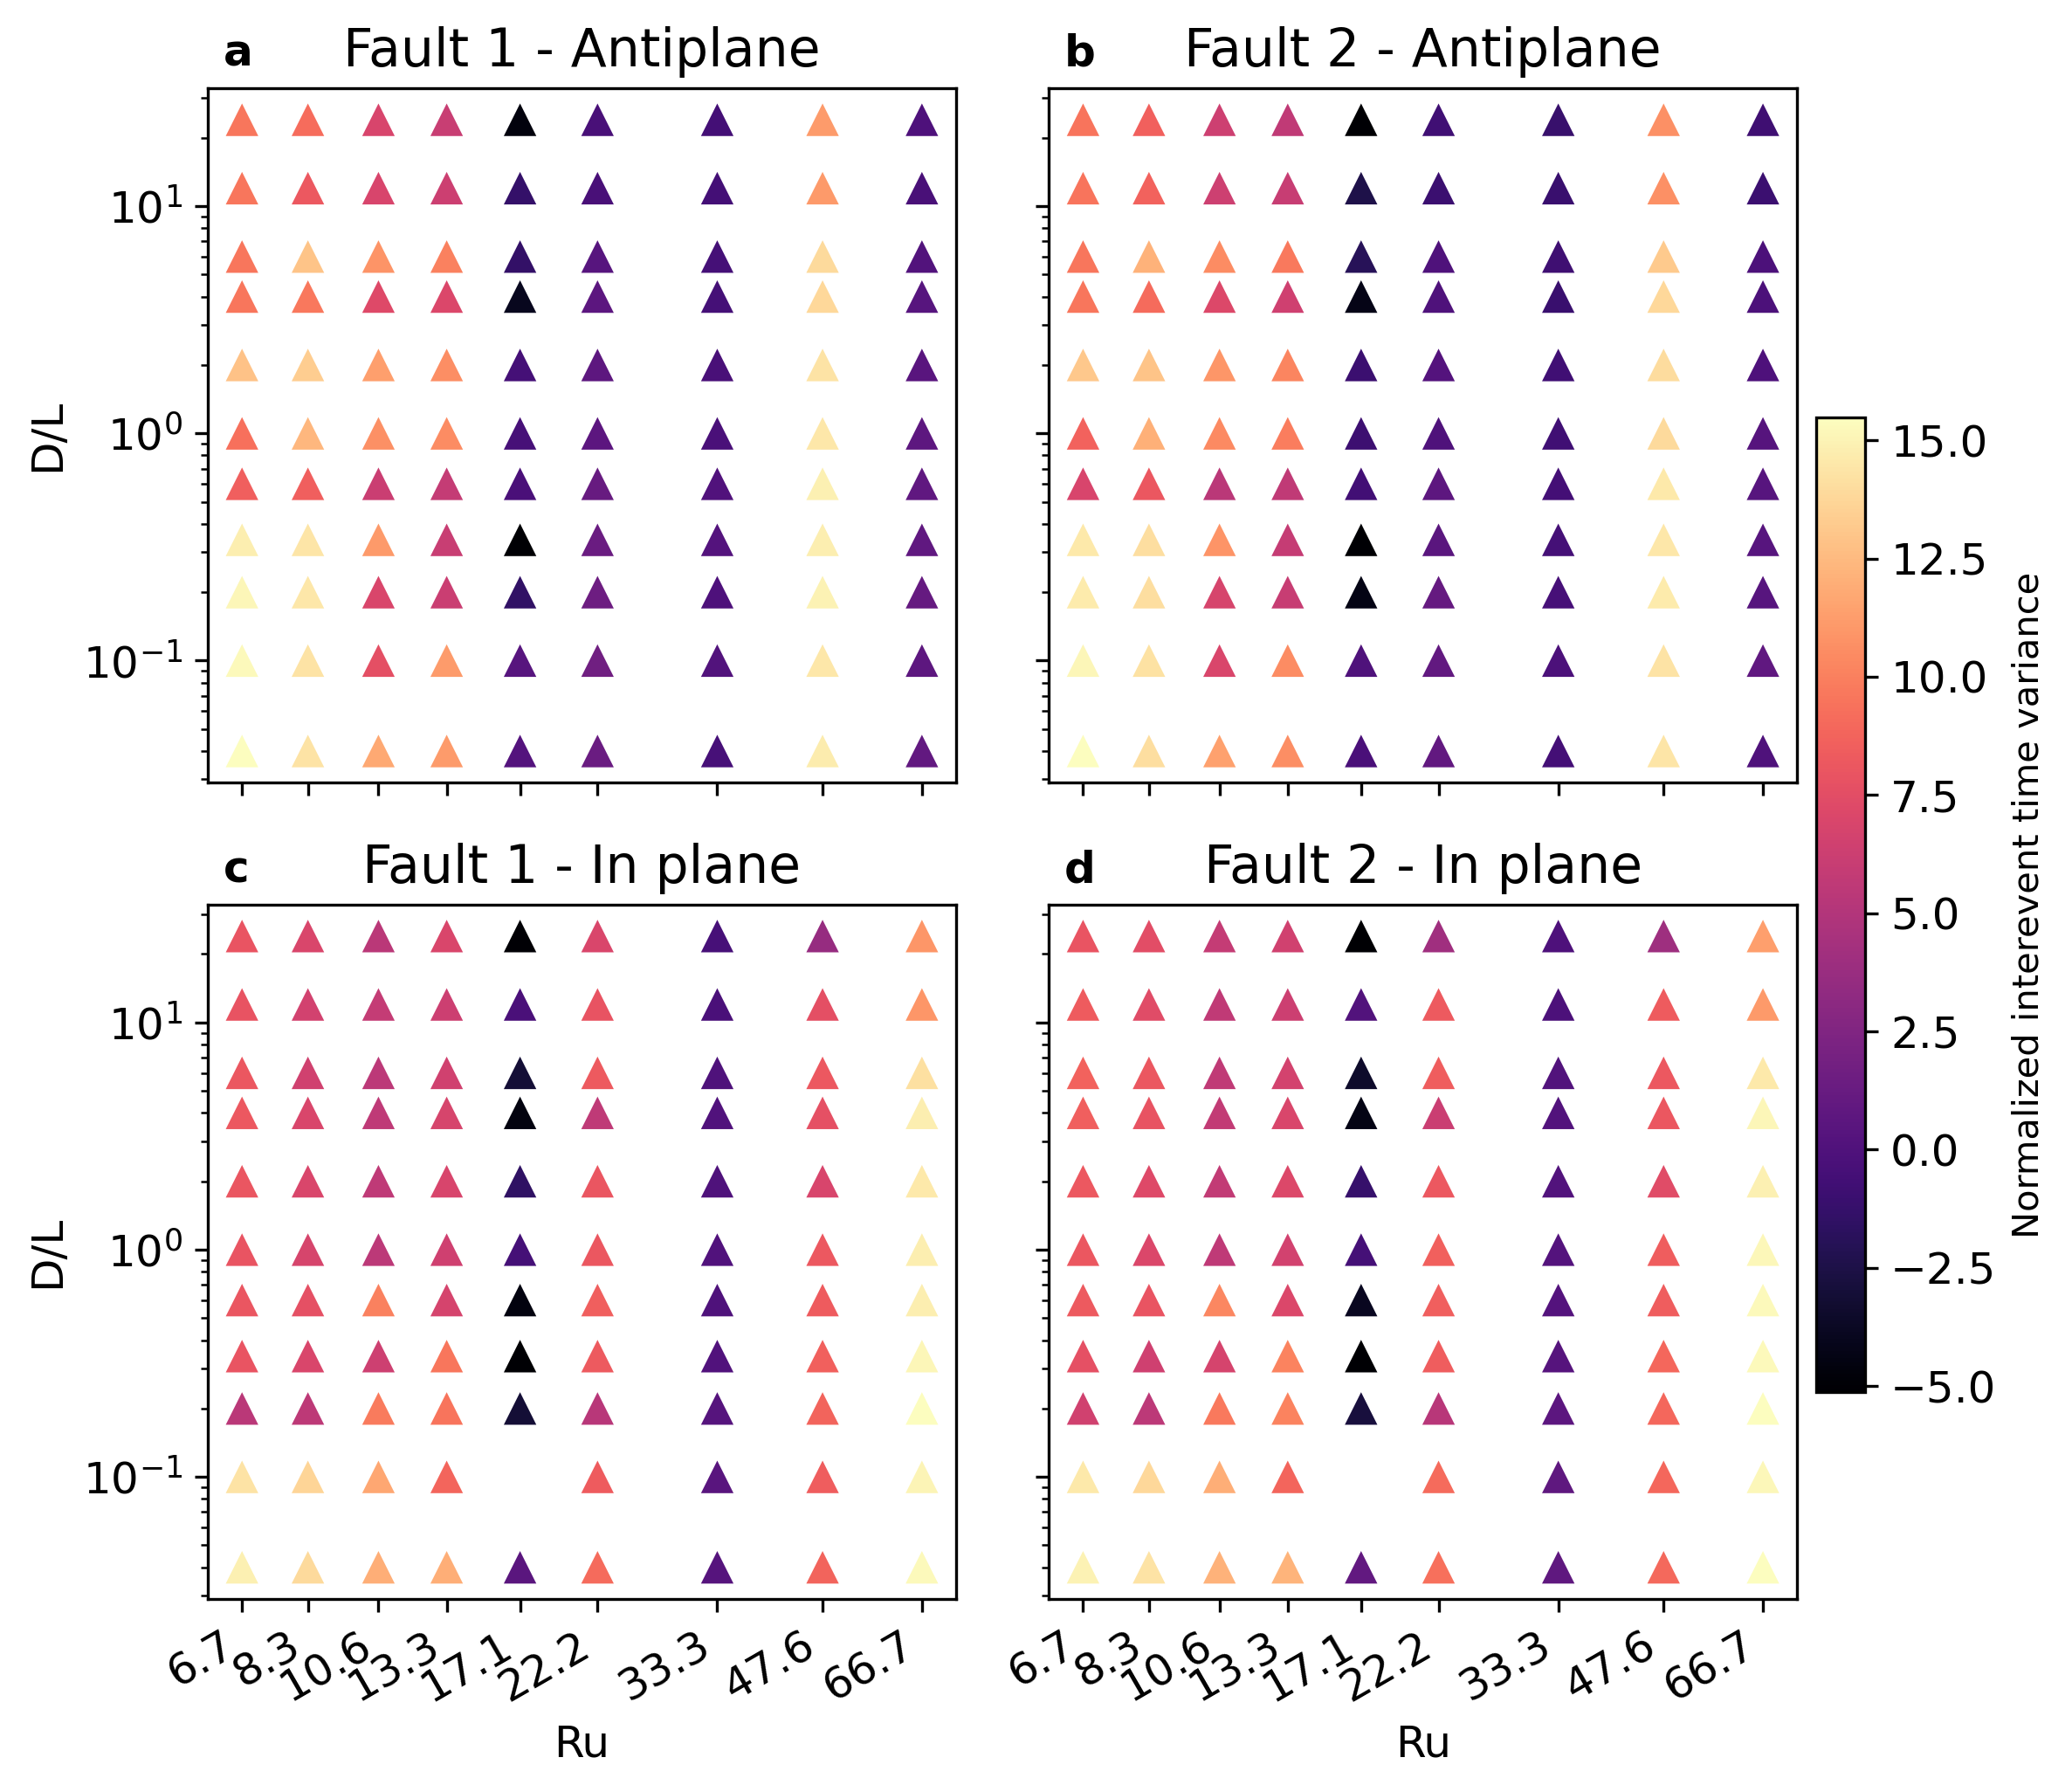

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7), dpi=300, sharex=True, sharey=True)

scatter = None

for i, loading in enumerate(["Antiplane", "In plane"]):
    data = two_faults_order[
        two_faults_order["Loading"].str.strip().str.lower() == loading.lower()
    ].copy()
    data["D"] = pd.to_numeric(data["D"], errors="coerce")
    data["Dc"] = pd.to_numeric(data["Dc"], errors="coerce")

    data["Ru"] = [
        utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L) for dc in data["Dc"]
    ]
    data["variance_f1"] = pd.to_numeric(data["variance_f1"], errors="coerce")
    data["variance_f2"] = pd.to_numeric(data["variance_f2"], errors="coerce")

    scatter = axes[i, 0].scatter(
        data["Ru"],
        data["D"] / 5,
        c=data["normalized_variance_f1"],
        cmap="magma",
        marker="^",
        edgecolor="none",
        s=80,
    )
    axes[i, 0].set_title(f"Fault 1 - {loading}")
    axes[0, 0].set_ylabel("D/L")
    axes[1, 0].set_xlabel("Ru")
    axes[i, 0].set_xscale("log")
    axes[i, 0].set_yscale("log")
    axes[i, 0].set_xticklabels([])
    axes[i, 0].xaxis.set_minor_locator(plt.NullLocator())
    if loading == "Antiplane":
        desired_ticks = data["Ru"].unique()

    axes[i, 0].set_xticks(desired_ticks)
    axes[i, 0].set_xticklabels(
        [f"{tick:.1f}" for tick in desired_ticks], rotation=30, ha="right"
    )

    scatter = axes[i, 1].scatter(
        data["Ru"],
        data["D"] / 5,
        c=data["normalized_variance_f2"],
        cmap="magma",
        edgecolor="none",
        marker="^",
        s=80,
    )
    axes[i, 1].set_title(f"Fault 2 - {loading}")
    axes[1, 0].set_ylabel("D/L")
    axes[1, 1].set_xlabel("Ru")
    axes[i, 1].set_yscale("log")
    axes[i, 1].set_xscale("log")
    axes[i, 1].set_xticklabels([])
    axes[i, 1].xaxis.set_minor_locator(plt.NullLocator())
    axes[i, 1].set_xticks(desired_ticks)
    axes[i, 1].set_xticklabels(
        [f"{tick:.1f}" for tick in desired_ticks], rotation=30, ha="right"
    )


cbar = fig.colorbar(scatter, ax=axes, orientation="vertical", fraction=0.03, pad=0.03)
cbar.set_label("Normalized interevent time variance", fontsize=10)

tags = ["a", "b", "c", "d"]
for idx, ax in enumerate(axes.flat):
    ax.text(
        0.02,
        1.08,
        tags[idx],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left",
    )
fig.subplots_adjust(wspace=0.1)
plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.savefig(
    "Summary figures/interevent_order_plots_tables/phase_space_time_normalized_variance.png",
    bbox_inches="tight",
)

Griffin plots

/Users/albamarrodriguezpadilla/Documents/Motorcycle_output_analysis/utils.py:803: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(memory_f1, burstiness_f1, color=color, marker=marker_shape, s=20, alpha=0.6, edgecolor='none')
/Users/albamarrodriguezpadilla/Documents/Motorcycle_output_analysis/utils.py:804: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(memory_f2, burstiness_f2, color=color, marker=marker_shape, s=20, alpha=0.6, edgecolor='none')
/Users/albamarrodriguezpadilla/Documents/Motorcycle_output_analysis/utils.py:803: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  Th

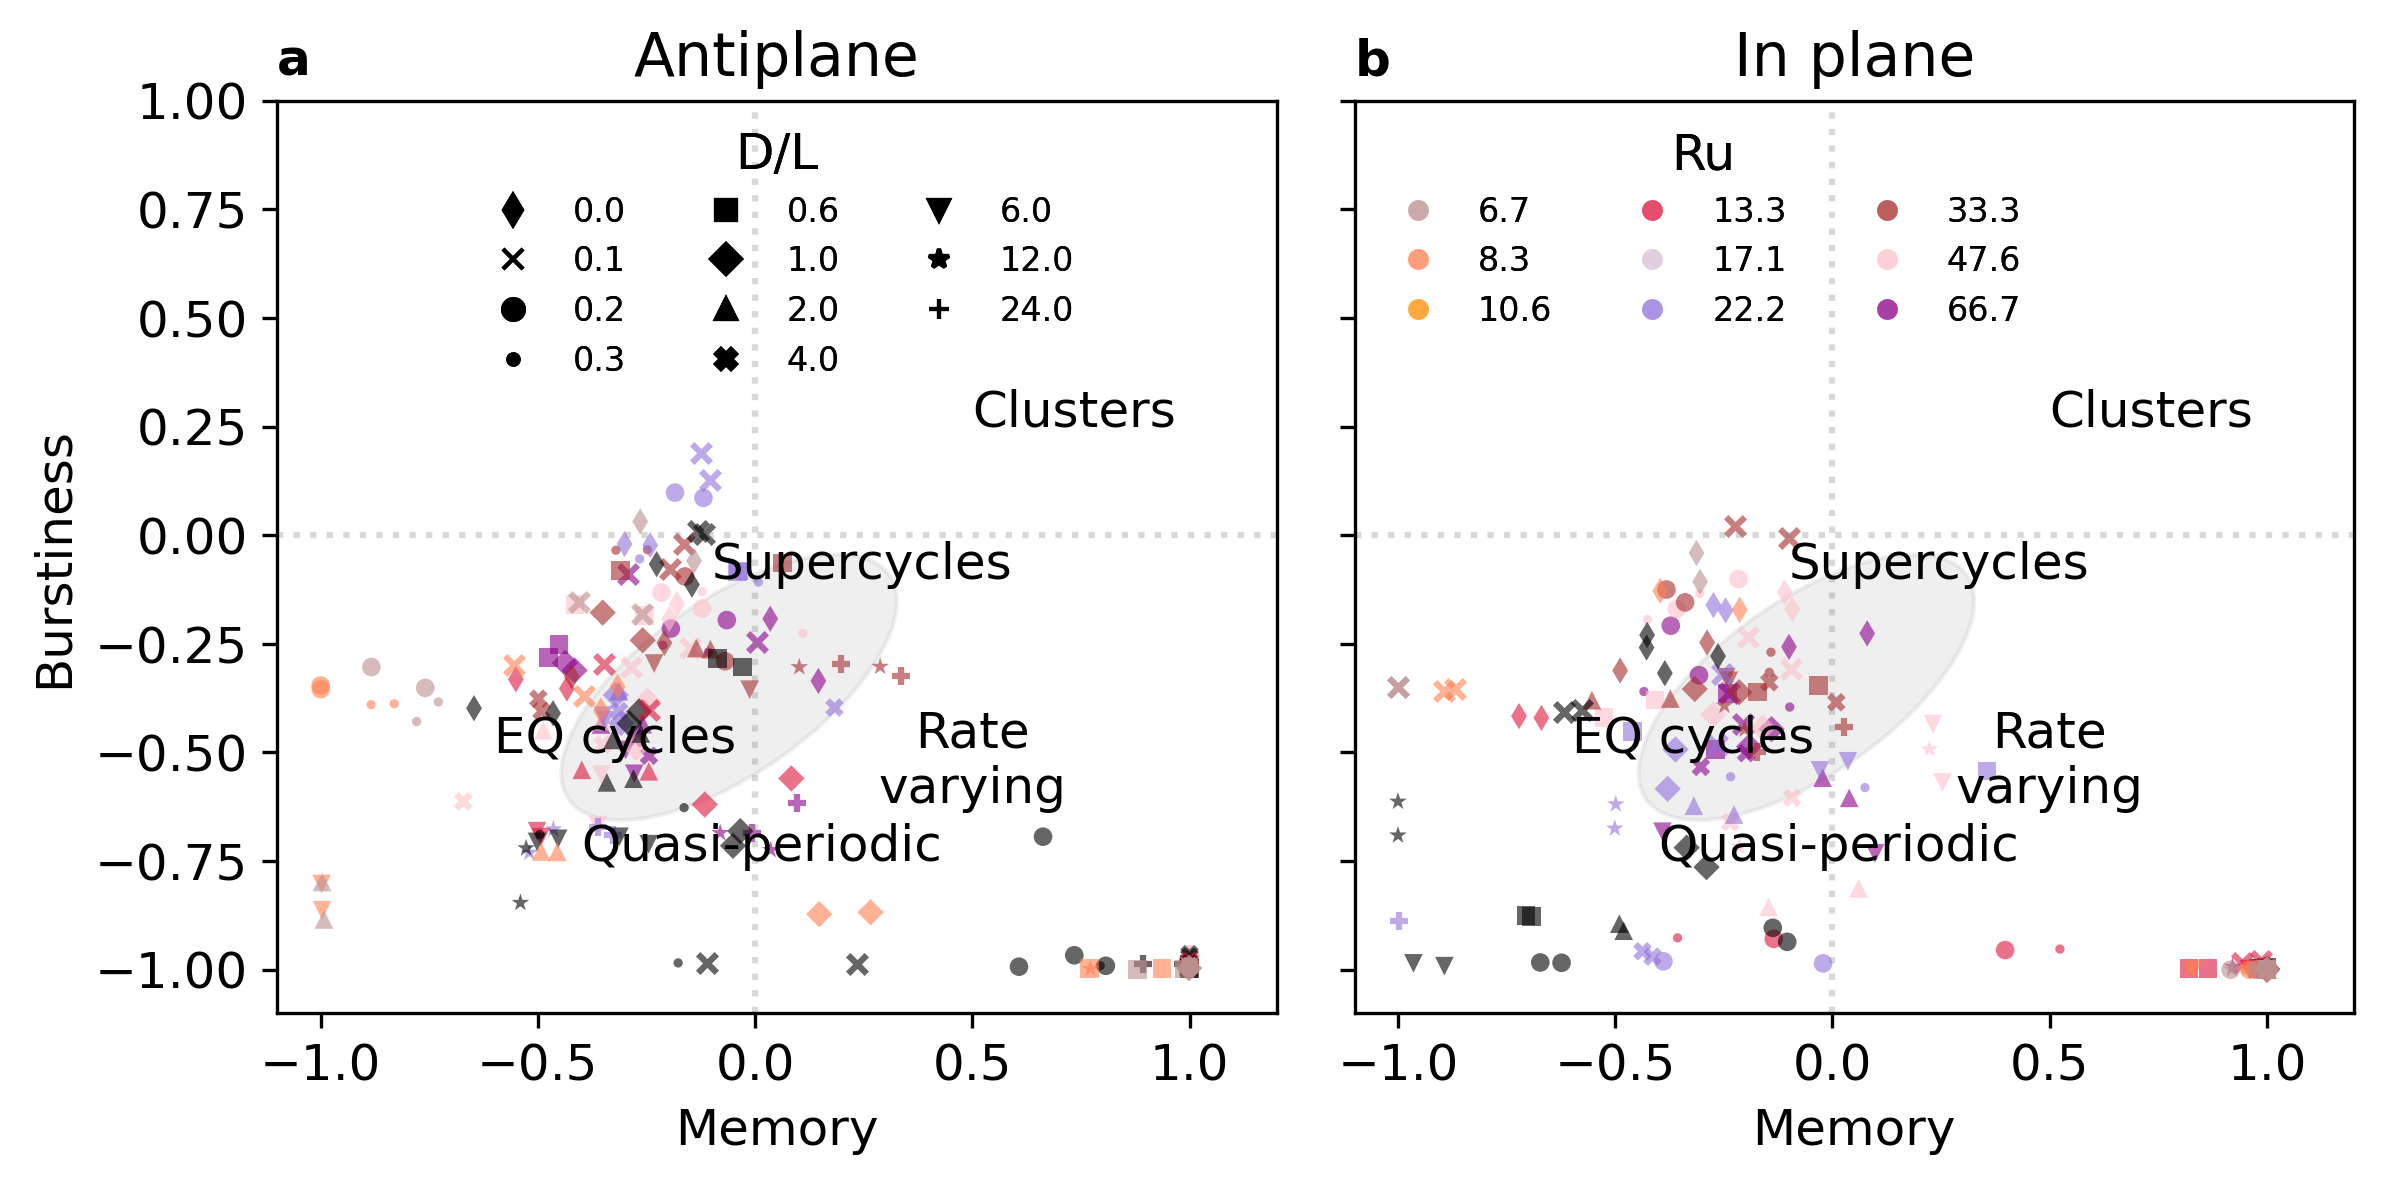

In [ ]:
two_faults_interevent_times = pd.read_csv(
    "code_output_data/interevent_times_two_faults_full_ruptures.csv"
)

marker_shapes = {
    0.2: "d",
    0.5: "x",
    1: "o",
    1.7: ".",
    3: "s",
    5: "D",
    10: "^",
    20: "X",
    30: "v",
    60: "*",
    120: "+",
}
# ru estimate
shear_mod = 30e9  # Shear modulus in Pa
a = 1e-2
b = a + 4e-3
sigma_o = 100e6  # normal stress Pa
L = 5000  # rate-weakening length

dc_to_ru = {}
for dc in [0.01, 0.008, 0.0063, 0.005, 0.0039, 0.003, 0.002, 0.0014, 0.001]:
    ru = utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L)
    dc_to_ru[dc] = ru

d_to_dl = {}
for d in [0.2, 0.5, 1, 1.7, 3, 5, 10, 20, 30, 60, 120]:
    dl = d / 5  # L = 5 km
    d_to_dl[d] = dl

ru_colors = {
    dc_to_ru[0.01]: "rosybrown",
    dc_to_ru[0.008]: "coral",
    dc_to_ru[0.0063]: "darkorange",
    dc_to_ru[0.005]: "crimson",
    dc_to_ru[0.0039]: "thistle",
    dc_to_ru[0.003]: "mediumpurple",
    dc_to_ru[0.002]: "brown",
    dc_to_ru[0.0014]: "pink",
    dc_to_ru[0.001]: "darkmagenta",
}


dc_colors = {
    0.01: "rosybrown",
    0.008: "coral",
    0.0063: "darkorange",
    0.005: "crimson",
    0.0039: "thistle",
    0.003: "mediumpurple",
    0.002: "brown",
    0.0014: "pink",
    0.001: "darkmagenta",
}

fig, (ax1, ax2) = plt.subplots(1, 2, dpi=300, figsize=(8, 4.5), sharey=True)

# ellipses from Griffin EQ cycle reference from Rajani
el1 = Ellipse(
    xy=(-0.06, -0.35), width=0.9, height=0.4, angle=35, color="0.7", alpha=0.2
)
el2 = Ellipse(
    xy=(-0.06, -0.35), width=0.9, height=0.4, angle=35, color="0.7", alpha=0.2
)
ax1.add_artist(el1)
ax1.set_aspect("equal")
ax2.add_artist(el2)
ax2.set_aspect("equal")

# legend for D/L and Ru values
shape_legend = [
    plt.Line2D(
        [0], [0], color="black", marker=marker_shapes[d], linestyle="", markersize=5
    )
    for d in marker_shapes.keys()
]
shape_legend_labels = [f"{d_to_dl[d]:.1f}" for d in marker_shapes.keys()]
color_legend = [
    plt.Line2D(
        [0],
        [0],
        color=ru_colors[ru],
        marker="o",
        linestyle="",
        alpha=0.5,
        markersize=5,
        markeredgecolor="none",
    )
    for ru in ru_colors.keys()
]
color_legend_labels = [f"{ru:.1f}" for ru in ru_colors.keys()]
legend1 = ax1.legend(
    shape_legend,
    shape_legend_labels,
    frameon=False,
    fontsize=8,
    title="D/L",
    loc="upper center",
    ncols=3,
)
fig.add_artist(legend1)
legend2 = ax2.legend(
    color_legend,
    color_legend_labels,
    frameon=False,
    fontsize=8,
    title="Ru",
    loc="upper left",
    ncols=3,
)
fig.add_artist(legend2)

antiplane_data = two_faults_interevent_times[
    two_faults_interevent_times["Loading"] == "Antiplane"
]
inplane_data = two_faults_interevent_times[
    two_faults_interevent_times["Loading"] == "In plane"
]

utils.Griffin_plot_interevent_times(antiplane_data, ax1, marker_shapes, dc_colors)
utils.Griffin_plot_interevent_times(inplane_data, ax2, marker_shapes, dc_colors)

for ax, title, label in zip([ax1, ax2], ["Antiplane", "In plane"], ["a", "b"]):
    if ax == ax1:
        ax.set_ylabel("Burstiness")
    ax.set_xlabel("Memory")
    ax.axvline(x=0, color="gray", linestyle=":", linewidth=1.5, alpha=0.3)
    ax.axhline(y=0, color="gray", linestyle=":", linewidth=1.5, alpha=0.3)
    ax.set_xlim(-1.1, 1.2)
    ax.set_ylim(-1.1, 1)
    ax.text(-0.4, -0.75, "Quasi-periodic")  # based on Griffin et al. (2020)
    ax.text(-0.6, -0.5, "EQ cycles")
    ax.text(-0.1, -0.1, "Supercycles")
    ax.text(0.5, 0.25, "Clusters")
    ax.text(0.5, -0.4, "Rate\nvarying", ha="center", va="top")
    ax.set_title(title)
    ax.text(
        0,
        1.07,
        f"{label}",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
    )

plt.tight_layout()
plt.savefig(
    "Summary figures/interevent_order_plots_tables/Griffin_plot.png",
    bbox_inches="tight",
)

### Deviations from benchmark - qualitative

/var/folders/kg/j5ms0y1x28l_gm2jtsf5j4pr0000gn/T/ipykernel_5085/398205885.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels([f"{tick:.1f}" for tick in desired_ticks], rotation=50, ha='center',fontsize=9)


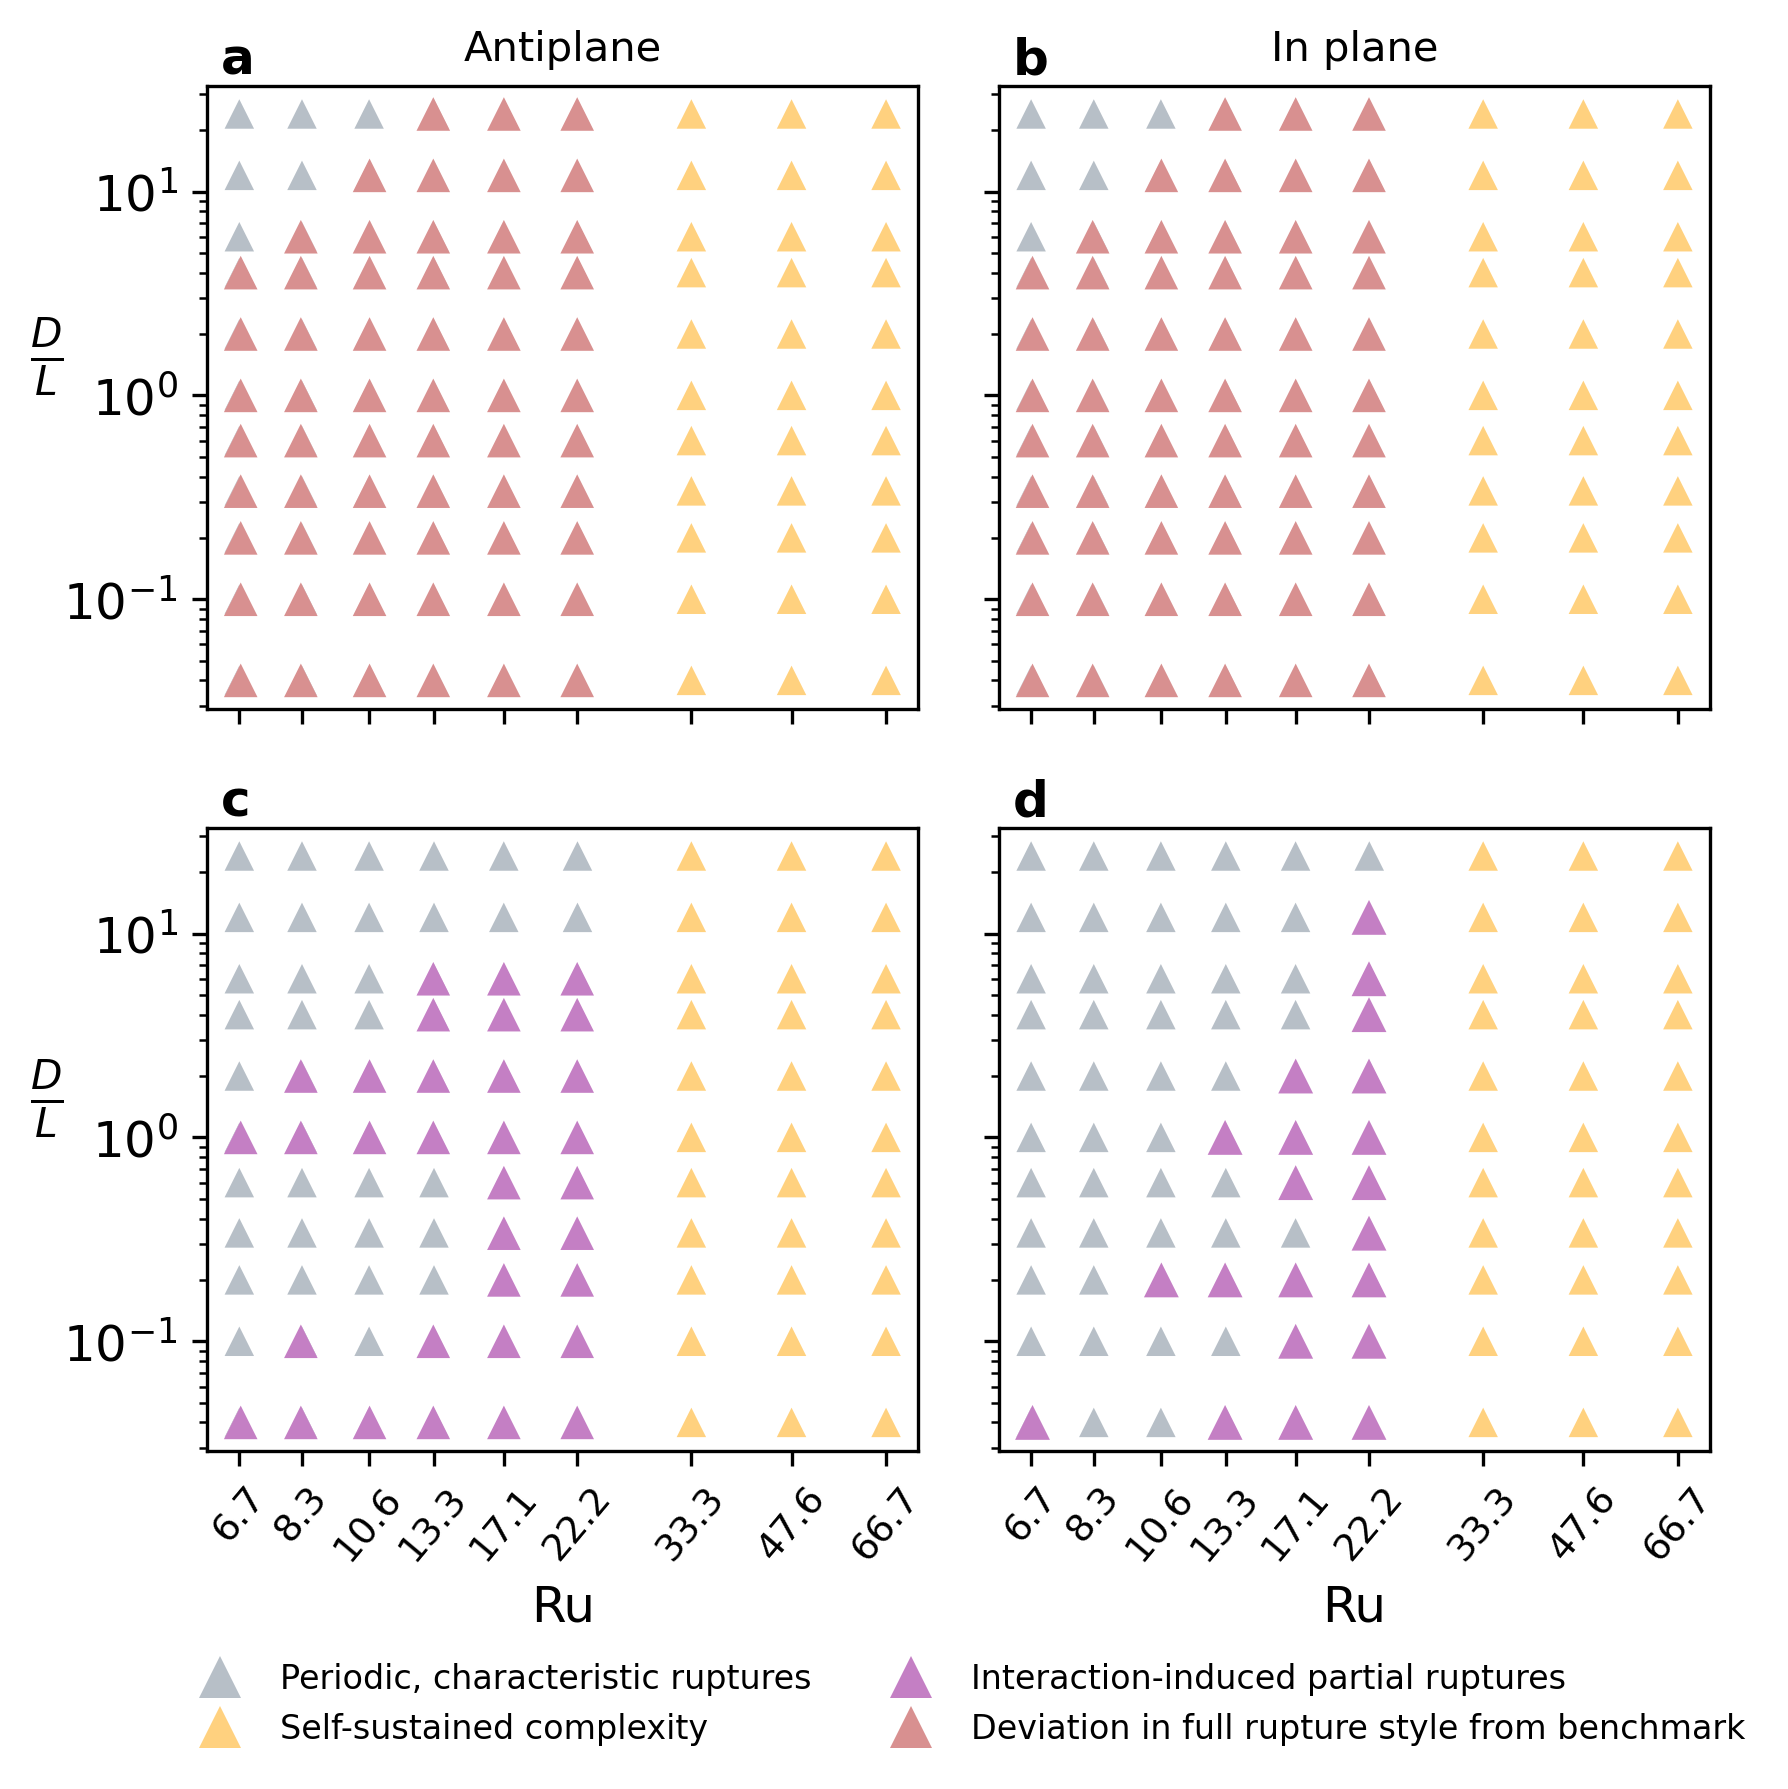

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6), dpi=300, sharex=True, sharey=True)

# Antiplane rupture style
# combinations of Dc and D/W with rupture styles differing from expectation in single fault benchmark (based on visual inspection of model outputs)
IP_PR_DW = np.array(
    [
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        6,
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        6,
        12,
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        6,
        12,
        24,
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        6,
        12,
        24,
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        6,
        12,
        24,
    ]
)
IP_PR_H = np.array(
    [
        6.7,
        6.7,
        6.7,
        6.7,
        6.7,
        6.7,
        6.7,
        6.7,
        8.3,
        8.3,
        8.3,
        8.3,
        8.3,
        8.3,
        8.3,
        8.3,
        8.3,
        10.6,
        10.6,
        10.6,
        10.6,
        10.6,
        10.6,
        10.6,
        10.6,
        10.6,
        10.6,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
    ]
)
D_W_matrix = np.tile(
    D_W_values, (len(Dc), 1)
)  # Make D_W a 2D matrix for easier indexing
for j in range(len(D_W_values)):
    colors = ["slategray"] * (len(Dc) - 3) + ["orange"] * 3
    axes[0, 0].scatter(
        Ru_values,
        D_W_matrix[:, j],
        marker="^",
        c=colors,
        edgecolor="none",
        s=50,
        alpha=0.5,
    )

axes[0, 0].scatter(
    IP_PR_H, IP_PR_DW, color="white", edgecolor="none", marker="^", s=65, alpha=1
)
axes[0, 0].scatter(
    IP_PR_H,
    IP_PR_DW,
    color="firebrick",
    edgecolor="none",
    marker="^",
    s=65,
    alpha=0.5,
    label="Interaction-induced partial ruptures",
)
axes[0, 0].set_ylabel(r"$\frac{D}{L}$", rotation=0, fontsize=14)
axes[0, 0].set_xscale("log")
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Antiplane", fontsize=10)

# In plane rupture styel
# combinations of Dc and D/W with rupture styles differing from expectation in single fault benchmark (based on visual inspection of model outputs)
IP_PR_DW = np.array(
    [
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        6,
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        6,
        12,
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        6,
        12,
        24,
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        6,
        12,
        24,
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        6,
        12,
        24,
    ]
)

IP_PR_H = np.array(
    [
        6.7,
        6.7,
        6.7,
        6.7,
        6.7,
        6.7,
        6.7,
        6.7,
        8.3,
        8.3,
        8.3,
        8.3,
        8.3,
        8.3,
        8.3,
        8.3,
        8.3,
        10.6,
        10.6,
        10.6,
        10.6,
        10.6,
        10.6,
        10.6,
        10.6,
        10.6,
        10.6,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
    ]
)


for j in range(len(D_W_values)):
    colors = ["slategray"] * (len(Dc) - 3) + ["orange"] * 3
    axes[0, 1].scatter(
        Ru_values,
        D_W_matrix[:, j],
        marker="^",
        c=colors,
        edgecolor="none",
        s=50,
        alpha=0.5,
    )

axes[0, 1].scatter(
    IP_PR_H, IP_PR_DW, color="white", edgecolor="none", marker="^", s=65, alpha=1
)
axes[0, 1].scatter(
    IP_PR_H,
    IP_PR_DW,
    color="firebrick",
    edgecolor="none",
    marker="^",
    s=65,
    alpha=0.5,
    label="Deviation in rupture style from benchmark",
)
axes[0, 1].set_xscale("log")
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("In plane", fontsize=10)

desired_ticks = np.unique(Ru_values)
axes[0, 0].set_xticklabels([])
axes[0, 0].xaxis.set_minor_locator(plt.NullLocator())
axes[0, 0].set_xticks(desired_ticks)
axes[0, 0].set_xticklabels(
    [f"{tick:.1f}" for tick in desired_ticks], rotation=30, ha="center", fontsize=9
)

# Antiplane PR
IP_PR_DW = np.array(
    [
        0.04,
        1,
        0.04,
        0.1,
        1,
        2,
        0.04,
        1,
        2,
        0.04,
        0.1,
        1,
        2,
        4,
        6,
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        6,
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        6,
    ]
)
IP_PR_H = np.array(
    [
        6.7,
        6.7,
        8.3,
        8.3,
        8.3,
        8.3,
        10.6,
        10.6,
        10.6,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        13.3,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
    ]
)

D_W_matrix = np.tile(
    D_W_values, (len(Dc), 1)
)  # Make D_W a 2D matrix for easier indexing
for j in range(len(D_W_values)):
    colors = ["slategray"] * (len(Dc) - 3) + ["orange"] * 3
    axes[1, 0].scatter(
        Ru_values,
        D_W_matrix[:, j],
        marker="^",
        c=colors,
        edgecolor="none",
        s=50,
        alpha=0.5,
    )

axes[1, 0].scatter(
    IP_PR_H, IP_PR_DW, color="white", edgecolor="none", marker="^", s=65, alpha=1
)
axes[1, 0].scatter(
    IP_PR_H,
    IP_PR_DW,
    color="darkmagenta",
    edgecolor="none",
    marker="^",
    s=65,
    alpha=0.5,
    label="Interaction-induced partial ruptures",
)

axes[1, 0].set_ylabel(r"$\frac{D}{L}$", rotation=0, fontsize=14)
axes[1, 0].set_xlabel("Ru")
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_xticklabels(
    [f"{tick:.1f}" for tick in desired_ticks], rotation=50, ha="center", fontsize=9
)

# in plane PR
for j in range(len(D_W_values)):
    colors = ["slategray"] * (len(Dc) - 3) + ["orange"] * 3
    axes[1, 1].scatter(
        Ru_values,
        D_W_matrix[:, j],
        marker="^",
        c=colors,
        s=50,
        alpha=0.5,
        edgecolor="none",
    )

IP_PR_H = np.array(
    [
        6.7,
        10.6,
        13.3,
        13.3,
        13.3,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        17.1,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
        22.2,
    ]
)
IP_PR_DW = np.array(
    [
        0.04,
        0.2,
        0.04,
        0.2,
        1,
        0.04,
        0.1,
        0.2,
        0.6,
        1,
        2,
        0.04,
        0.1,
        0.2,
        0.339,
        0.6,
        1,
        2,
        4,
        6,
        12,
    ]
)

axes[1, 1].scatter(
    IP_PR_H, IP_PR_DW, color="white", edgecolor="none", marker="^", s=70, alpha=1
)
axes[1, 1].scatter(
    IP_PR_H,
    IP_PR_DW,
    color="darkmagenta",
    edgecolor="none",
    marker="^",
    s=70,
    alpha=0.5,
    label="Interaction-induced partial ruptures",
)

axes[1, 1].set_xlabel("Ru")
axes[1, 1].set_xscale("log")
axes[1, 1].set_yscale("log")

desired_ticks = np.unique(Ru_values)
axes[1, 1].set_xticklabels([])
axes[1, 1].xaxis.set_minor_locator(plt.NullLocator())
axes[1, 1].set_xticks(desired_ticks)
axes[1, 1].set_xticklabels(
    [f"{tick:.1f}" for tick in desired_ticks], rotation=50, ha="center", fontsize=9
)


legend_elements = [
    Line2D(
        [0],
        [0],
        marker="^",
        color="none",
        markeredgecolor="none",
        alpha=0.5,
        markerfacecolor="slategray",
        markersize=10,
        label="Periodic, characteristic ruptures",
    ),
    Line2D(
        [0],
        [0],
        marker="^",
        color="none",
        markeredgecolor="none",
        alpha=0.5,
        markerfacecolor="orange",
        markersize=10,
        label="Self-sustained complexity",
    ),
    Line2D(
        [0],
        [0],
        marker="^",
        color="none",
        markeredgecolor="none",
        alpha=0.5,
        markerfacecolor="darkmagenta",
        markersize=10,
        label="Interaction-induced partial ruptures",
    ),
    Line2D(
        [0],
        [0],
        marker="^",
        color="none",
        markeredgecolor="none",
        alpha=0.5,
        markerfacecolor="firebrick",
        markersize=10,
        label="Deviation in full rupture style from benchmark",
    ),
]
fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.55, 0),
    ncol=2,
    fontsize=8,
    frameon=False,
)
tags = ["a", "b", "c", "d"]
for idx, ax in enumerate(axes.flat):
    ax.text(
        0.02,
        1.08,
        tags[idx],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left",
    )

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(
    "Summary figures/interevent_order_plots_tables/phase_space_rupture_styles_partial_rupture_diff_from_single_fault_benchmark.png",
    bbox_inches="tight",
)